<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/30_45Years_Final_Zambia_CC_Sept_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Path to your .dta file
file_path = '/content/drive/MyDrive/zambia_CC_BC.dta'

# Read the .dta file into a pandas DataFrame
try:
    df = pd.read_stata(file_path)
    print("File imported successfully! First 5 rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and Google Drive is mounted.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File imported successfully! First 5 rows:


,v000,v001,v005,v007,v012,v025,v106,v151,v152,v157,...,v481,v484a,v484b,v501,v525,v763a,v763b,v763c,v781,v836
0,ZM8,1,748300,2024,42,urban,primary,male,44,not at all,...,no,no,no,married,22,no,no,no,yes,2.0
1,ZM8,1,748300,2024,42,urban,higher,female,41,at least once a week,...,yes,yes,yes,married,17,no,no,no,yes,3.0
2,ZM8,1,748300,2024,24,urban,primary,female,24,at least once a week,...,no,no,no,no longer living together/separated,16,no,yes,yes,yes,3.0
3,ZM8,1,748300,2024,22,urban,secondary,male,26,not at all,...,no,no,no,married,15,yes,no,no,yes,5.0
4,ZM8,1,748300,2024,32,urban,primary,female,32,at least once a week,...,no,no,yes,never in union,15,no,no,no,yes,3.0


In [83]:
# Assuming your dataframe is df

rename_dict = {
    "v012": "respondent_age",
    "v025": "residence_type",
    "v106": "highest_edu_level",
    "v151": "sex_of_household_head",
    "v152": "age_of_household_head",
    "v157": "freq_read_newspaper",
    "v158": "freq_listen_radio",
    "v159": "freq_watch_tv",
    "v169a": "owns_mobile_phone",
    "v190": "wealth_index",
    "v312": "current_contraceptive_method",
    "v394": "visited_health_facility_12mo",
    "v463a": "smokes_cigarettes",
    "v467b": "permission_to_medical_Vist",
    "v467c": "money_needed_for_medical_vist",
    "v467d": "distance_to_health_facility",
    "v467e": "transport_for_medical_visit",
    "v467k": "waiting_time_concern_at_HF",
    "v481": "covered_by_health_insurance",
    "v484a": "breast_exam_by_provider",
    "v484b": "cervical_cancer_tested",
    "v501": "marital_status",
    "v525": "age_at_first_sex",
    "v763a": "STI_last_12mo",
    "v763b": "genital_sore_last_12mo",
    "v763c": "genital_discharge_last_12mo",
    "v781": "ever_tested_hiv",
    "v836": "total_lifetime_sex_partners"
}

# Apply renaming
df = df.rename(columns=rename_dict)

df.head()


,v000,v001,v005,v007,respondent_age,residence_type,highest_edu_level,sex_of_household_head,age_of_household_head,freq_read_newspaper,...,covered_by_health_insurance,breast_exam_by_provider,cervical_cancer_tested,marital_status,age_at_first_sex,STI_last_12mo,genital_sore_last_12mo,genital_discharge_last_12mo,ever_tested_hiv,total_lifetime_sex_partners
0,ZM8,1,748300,2024,42,urban,primary,male,44,not at all,...,no,no,no,married,22,no,no,no,yes,2.0
1,ZM8,1,748300,2024,42,urban,higher,female,41,at least once a week,...,yes,yes,yes,married,17,no,no,no,yes,3.0
2,ZM8,1,748300,2024,24,urban,primary,female,24,at least once a week,...,no,no,no,no longer living together/separated,16,no,yes,yes,yes,3.0
3,ZM8,1,748300,2024,22,urban,secondary,male,26,not at all,...,no,no,no,married,15,yes,no,no,yes,5.0
4,ZM8,1,748300,2024,32,urban,primary,female,32,at least once a week,...,no,no,yes,never in union,15,no,no,no,yes,3.0


In [84]:
df.columns

Index(['v000', 'v001', 'v005', 'v007', 'respondent_age', 'residence_type',
       'highest_edu_level', 'sex_of_household_head', 'age_of_household_head',
       'freq_read_newspaper', 'freq_listen_radio', 'freq_watch_tv',
       'owns_mobile_phone', 'wealth_index', 'current_contraceptive_method',
       'visited_health_facility_12mo', 'smokes_cigarettes',
       'permission_to_medical_Vist', 'money_needed_for_medical_vist',
       'distance_to_health_facility', 'transport_for_medical_visit',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'genital_sore_last_12mo',
       'genital_discharge_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners'],
      dtype='object')

In [85]:
import numpy as np
import pandas as pd

# 1. Process 'freq_read_newspaper' from its original categorical strings to 'No'/'Yes', then to 0/1
df['freq_read_newspaper'] = df['freq_read_newspaper'].replace({
    "not at all": "No",
    "less than once a week": "No",
    "at least once a week": "Yes",
    "almost every day": "Yes"
})
df['freq_read_newspaper'] = df['freq_read_newspaper'].map({'No': 0, 'Yes': 1})

# 2. Process 'freq_listen_radio' from 'No'/'Yes' strings to 0/1
# This column is already 'No'/'Yes' strings due to prior cell execution.
df['freq_listen_radio'] = df['freq_listen_radio'].map({'No': 0, 'Yes': 1})

# 3. Process 'freq_watch_tv' from 'No'/'Yes' strings to 0/1
# This column is already 'No'/'Yes' strings due to prior cell execution.
df['freq_watch_tv'] = df['freq_watch_tv'].map({'No': 0, 'Yes': 1})

# 4. Create 'Media_exposure' column in df
# It will be 1 if any of 'freq_read_newspaper', 'freq_listen_radio', or 'freq_watch_tv' is 1 ('Yes'), else 0.
df['Media_exposure'] = np.where(
    (df['freq_read_newspaper'] == 1) |
    (df['freq_listen_radio'] == 1) |
    (df['freq_watch_tv'] == 1),
    1,  # Yes
    0   # No
)

# 5. Drop the individual media columns from df
df = df.drop(columns=['freq_read_newspaper', 'freq_listen_radio', 'freq_watch_tv'])

# Display the updated DataFrame head and the value counts of the new column
print("DataFrame head after creating Media_exposure and dropping original columns:")
display(df.head())
print("\nValue counts for 'Media_exposure':")
print(df['Media_exposure'].value_counts())


DataFrame head after creating Media_exposure and dropping original columns:


/tmp/ipykernel_1507/2967137131.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['freq_read_newspaper'] = df['freq_read_newspaper'].replace({


,v000,v001,v005,v007,respondent_age,residence_type,highest_edu_level,sex_of_household_head,age_of_household_head,owns_mobile_phone,...,breast_exam_by_provider,cervical_cancer_tested,marital_status,age_at_first_sex,STI_last_12mo,genital_sore_last_12mo,genital_discharge_last_12mo,ever_tested_hiv,total_lifetime_sex_partners,Media_exposure
0,ZM8,1,748300,2024,42,urban,primary,male,44,yes,...,no,no,married,22,no,no,no,yes,2.0,0
1,ZM8,1,748300,2024,42,urban,higher,female,41,yes,...,yes,yes,married,17,no,no,no,yes,3.0,1
2,ZM8,1,748300,2024,24,urban,primary,female,24,yes,...,no,no,no longer living together/separated,16,no,yes,yes,yes,3.0,1
3,ZM8,1,748300,2024,22,urban,secondary,male,26,yes,...,no,no,married,15,yes,no,no,yes,5.0,0
4,ZM8,1,748300,2024,32,urban,primary,female,32,yes,...,no,yes,never in union,15,no,no,no,yes,3.0,1



Value counts for 'Media_exposure':
Media_exposure
0    12788
1     1163
Name: count, dtype: int64


In [86]:
df["current_contraceptive_method"] = df["current_contraceptive_method"].replace({

    # Hormonal
    "pill": "Hormonal",
    "injections": "Hormonal",
    "implants/norplant": "Hormonal",
    "emergency contraception": "Hormonal",
    "lactational amenorrhea (lam)": "Hormonal",

    # Non-hormonal
    "not using": "Non-Hormonal",
    "iud": "Non-Hormonal",
    "male condom": "Non-Hormonal",
    "female condom": "Non-Hormonal",
    "female sterilization": "Non-Hormonal",
    "periodic abstinence": "Non-Hormonal",
    "withdrawal": "Non-Hormonal",
    "other traditional": "Non-Hormonal",
    "other modern method": "Non-Hormonal",
    "standard days method (sdm)": "Non-Hormonal"
})


/tmp/ipykernel_1507/214665719.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["current_contraceptive_method"] = df["current_contraceptive_method"].replace({


In [87]:
df = df[df['respondent_age'] >= 30]
print(f"Shape of DataFrame after removing observations with age < 30: {df.shape}")

Shape of DataFrame after removing observations with age < 30: (5864, 30)


In [88]:
import pandas as pd

# Define the bins and labels for the age categories
# The minimum age in the DataFrame is 30 due to previous filtering.
# The max age is dynamically found to ensure the last bin covers all higher ages.
min_age_in_df = df['respondent_age'].min()
max_age_in_df = df['respondent_age'].max()

# Bins are set to create the desired inclusive ranges.
# We start the first bin just below the min_age_in_df to properly include it with include_lowest=True.
bins = [min_age_in_df - 1, 35, 40, 45, max_age_in_df + 1]
labels = ['30-35', '36-40', '41-45', '>=46']

# Create the new categorical column 'Women_Age_Category'
df['Women_Age_Category'] = pd.cut(
    df['respondent_age'],
    bins=bins,
    labels=labels,
    right=True, # Includes the rightmost bin edge
    include_lowest=True # Includes the left boundary of the first bin
)

# Display the value counts for the new column to verify categories
print("Value counts for 'Women_Age_Category':")
print(df['Women_Age_Category'].value_counts(dropna=False))

# Display the head of the DataFrame with the new column
print("\nDataFrame head with new 'Women_Age_Category' column:")
display(df[['respondent_age', 'Women_Age_Category']].head())

Value counts for 'Women_Age_Category':
Women_Age_Category
30-35    2230
36-40    1588
41-45    1256
>=46      790
Name: count, dtype: int64

DataFrame head with new 'Women_Age_Category' column:


,respondent_age,Women_Age_Category
0,42,41-45
1,42,41-45
4,32,30-35
6,36,36-40
11,49,>=46


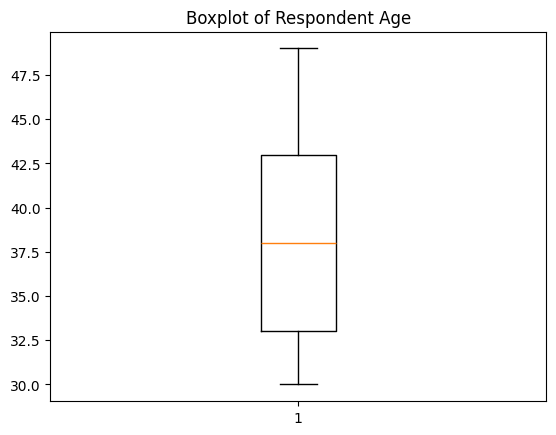

In [89]:
import matplotlib.pyplot as plt

plt.boxplot(df['respondent_age'])
plt.title("Boxplot of Respondent Age")
plt.show()


In [90]:
# Min-Max Normalization
df['respondent_age_scaled'] = (df['respondent_age'] - df['respondent_age'].min()) / \
                                  (df['respondent_age'].max() - df['respondent_age'].min())

# Display first few rows to check
print(df[['respondent_age_scaled', 'respondent_age']].head())


    respondent_age_scaled  respondent_age
0                0.631579              42
1                0.631579              42
4                0.105263              32
6                0.315789              36
11               1.000000              49


In [91]:
import pandas as pd
import numpy as np

# Example: your dataframe is df and the column is 'age_at_first_sex'

def recategorize_age(x):
    # Handle non-numeric values first
    if pd.isna(x):
        return np.nan
    if isinstance(x, str) and x.lower() == "not had sex":
        return ">18"

    # Convert to numeric if it's a string number
    try:
        x = float(x)
    except:
        return np.nan

    # Categorize
    if x <= 18:
        return "<=18"
    elif x > 18:
        return ">18"
    else:
        return np.nan

# Apply to dataframe
df["age_at_first_sex"] = df["age_at_first_sex"].apply(recategorize_age)

# View result
df["age_at_first_sex"].value_counts(dropna=False)

,count
age_at_first_sex,
<=18,4854
>18,1010


In [92]:
df['total_lifetime_sex_partners'].dtype
df['total_lifetime_sex_partners'].unique()  # see if there are unexpected strings


[2.0, 3.0, 5.0, 4.0, 7.0, ..., 13.0, 23.0, 27.0, 50.0, 29.0]
Length: 28
Categories (28, object): [1.0 < 2.0 < 3.0 < 4.0 ... 47.0 < 50.0 < '95+' < 'don't know']

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace specific strings with 0
df['total_lifetime_sex_partners'] = df['total_lifetime_sex_partners'].replace({
    '95+': 0,
    "don't know": 0
})

# Convert the column to numeric (coerce any other invalid entries to 0)
df['total_lifetime_sex_partners'] = pd.to_numeric(
    df['total_lifetime_sex_partners'], errors='coerce'
).fillna(0)

# Categorize total_lifetime_sex_partners with new labels
df['total_lifetime_sex_partners'] = df['total_lifetime_sex_partners'].apply(lambda x: '1 partner' if x <= 1 else '>=2 partners')

# Display the value counts for the new categories
print(df['total_lifetime_sex_partners'].value_counts())

total_lifetime_sex_partners
>=2 partners    4049
1 partner       1815
Name: count, dtype: int64


/tmp/ipykernel_1507/461527998.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['total_lifetime_sex_partners'] = df['total_lifetime_sex_partners'].replace({
/tmp/ipykernel_1507/461527998.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['total_lifetime_sex_partners'] = df['total_lifetime_sex_partners'].replace({


In [94]:
missing_percentages = df.isnull().sum() / len(df) * 100
missing_percentages_df = pd.DataFrame({"Missing Percentage": missing_percentages})

print("Percentage of missing values for each variable:")
print(missing_percentages_df)

Percentage of missing values for each variable:
                               Missing Percentage
v000                                          0.0
v001                                          0.0
v005                                          0.0
v007                                          0.0
respondent_age                                0.0
residence_type                                0.0
highest_edu_level                             0.0
sex_of_household_head                         0.0
age_of_household_head                         0.0
owns_mobile_phone                             0.0
wealth_index                                  0.0
current_contraceptive_method                  0.0
visited_health_facility_12mo                  0.0
smokes_cigarettes                             0.0
permission_to_medical_Vist                    0.0
money_needed_for_medical_vist                 0.0
distance_to_health_facility                   0.0
transport_for_medical_visit                   0.0
wa

In [95]:
df.head()

,v000,v001,v005,v007,respondent_age,residence_type,highest_edu_level,sex_of_household_head,age_of_household_head,owns_mobile_phone,...,marital_status,age_at_first_sex,STI_last_12mo,genital_sore_last_12mo,genital_discharge_last_12mo,ever_tested_hiv,total_lifetime_sex_partners,Media_exposure,Women_Age_Category,respondent_age_scaled
0,ZM8,1,748300,2024,42,urban,primary,male,44,yes,...,married,>18,no,no,no,yes,>=2 partners,0,41-45,0.631579
1,ZM8,1,748300,2024,42,urban,higher,female,41,yes,...,married,<=18,no,no,no,yes,>=2 partners,1,41-45,0.631579
4,ZM8,1,748300,2024,32,urban,primary,female,32,yes,...,never in union,<=18,no,no,no,yes,>=2 partners,1,30-35,0.105263
6,ZM8,1,748300,2024,36,urban,secondary,female,36,yes,...,widowed,<=18,no,no,no,yes,>=2 partners,0,36-40,0.315789
11,ZM8,1,748300,2024,49,urban,no education,male,59,no,...,married,<=18,no,no,no,yes,>=2 partners,0,>=46,1.000000


In [96]:
df.columns

Index(['v000', 'v001', 'v005', 'v007', 'respondent_age', 'residence_type',
       'highest_edu_level', 'sex_of_household_head', 'age_of_household_head',
       'owns_mobile_phone', 'wealth_index', 'current_contraceptive_method',
       'visited_health_facility_12mo', 'smokes_cigarettes',
       'permission_to_medical_Vist', 'money_needed_for_medical_vist',
       'distance_to_health_facility', 'transport_for_medical_visit',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'genital_sore_last_12mo',
       'genital_discharge_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners', 'Media_exposure', 'Women_Age_Category',
       'respondent_age_scaled'],
      dtype='object')

In [98]:
df = df.drop(columns=['age_of_household_head'])
print("Columns after dropping 'age_of_household_head':")
print(df.columns)

Columns after dropping 'age_of_household_head':
Index(['v000', 'v001', 'v005', 'v007', 'respondent_age', 'residence_type',
       'highest_edu_level', 'sex_of_household_head', 'owns_mobile_phone',
       'wealth_index', 'current_contraceptive_method',
       'visited_health_facility_12mo', 'smokes_cigarettes',
       'permission_to_medical_Vist', 'money_needed_for_medical_vist',
       'distance_to_health_facility', 'transport_for_medical_visit',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'genital_sore_last_12mo',
       'genital_discharge_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners', 'Media_exposure', 'Women_Age_Category',
       'respondent_age_scaled'],
      dtype='object')


In [99]:
print(df['marital_status'].value_counts(dropna=False))

marital_status
married                                4169
divorced                                713
never in union                          340
widowed                                 324
no longer living together/separated     265
living with partner                      53
Name: count, dtype: int64


In [100]:
df['marital_status'] = df['marital_status'].replace({
    'married': 'Married',
    'never in union': 'Single',
    'divorced': 'Widowed/Divorced/Separated',
    'no longer living together/separated': 'Widowed/Divorced/Separated',
    'widowed': 'Widowed/Divorced/Separated',
    'living with partner': 'Married' # Group 'Living with partner' with 'Married'
})

print("Value counts for 'marital_status' after renaming and grouping:")
print(df['marital_status'].value_counts(dropna=False))

Value counts for 'marital_status' after renaming and grouping:
marital_status
Married                       4222
Widowed/Divorced/Separated    1302
Single                         340
Name: count, dtype: int64


/tmp/ipykernel_1507/1308625106.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['marital_status'] = df['marital_status'].replace({


In [101]:
df.columns

Index(['v000', 'v001', 'v005', 'v007', 'respondent_age', 'residence_type',
       'highest_edu_level', 'sex_of_household_head', 'owns_mobile_phone',
       'wealth_index', 'current_contraceptive_method',
       'visited_health_facility_12mo', 'smokes_cigarettes',
       'permission_to_medical_Vist', 'money_needed_for_medical_vist',
       'distance_to_health_facility', 'transport_for_medical_visit',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'genital_sore_last_12mo',
       'genital_discharge_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners', 'Media_exposure', 'Women_Age_Category',
       'respondent_age_scaled'],
      dtype='object')

In [103]:
df = df.drop(['genital_sore_last_12mo', 'genital_discharge_last_12mo', 'permission_to_medical_Vist', 'transport_for_medical_visit', 'money_needed_for_medical_vist'], axis=1)

In [104]:
df.columns

Index(['v000', 'v001', 'v005', 'v007', 'respondent_age', 'residence_type',
       'highest_edu_level', 'sex_of_household_head', 'owns_mobile_phone',
       'wealth_index', 'current_contraceptive_method',
       'visited_health_facility_12mo', 'smokes_cigarettes',
       'distance_to_health_facility', 'waiting_time_concern_at_HF',
       'covered_by_health_insurance', 'breast_exam_by_provider',
       'cervical_cancer_tested', 'marital_status', 'age_at_first_sex',
       'STI_last_12mo', 'ever_tested_hiv', 'total_lifetime_sex_partners',
       'Media_exposure', 'Women_Age_Category', 'respondent_age_scaled'],
      dtype='object')

In [105]:
selected_columns = [
    'v005','respondent_age', 'residence_type',
       'highest_edu_level', 'sex_of_household_head', 'owns_mobile_phone',
       'wealth_index', 'current_contraceptive_method',
       'visited_health_facility_12mo', 'smokes_cigarettes',
       'distance_to_health_facility', 'waiting_time_concern_at_HF',
       'covered_by_health_insurance', 'breast_exam_by_provider',
       'cervical_cancer_tested', 'marital_status', 'age_at_first_sex',
       'STI_last_12mo', 'ever_tested_hiv', 'total_lifetime_sex_partners',
       'Media_exposure', 'Women_Age_Category', 'respondent_age_scaled'
]

df_selected = df[selected_columns]
display(df_selected.head())

,v005,respondent_age,residence_type,highest_edu_level,sex_of_household_head,owns_mobile_phone,wealth_index,current_contraceptive_method,visited_health_facility_12mo,smokes_cigarettes,...,breast_exam_by_provider,cervical_cancer_tested,marital_status,age_at_first_sex,STI_last_12mo,ever_tested_hiv,total_lifetime_sex_partners,Media_exposure,Women_Age_Category,respondent_age_scaled
0,748300,42,urban,primary,male,yes,richer,Non-Hormonal,yes,no,...,no,no,Married,>18,no,yes,>=2 partners,0,41-45,0.631579
1,748300,42,urban,higher,female,yes,richest,Non-Hormonal,yes,no,...,yes,yes,Married,<=18,no,yes,>=2 partners,1,41-45,0.631579
4,748300,32,urban,primary,female,yes,poorer,Hormonal,yes,no,...,no,yes,Single,<=18,no,yes,>=2 partners,1,30-35,0.105263
6,748300,36,urban,secondary,female,yes,richer,Hormonal,yes,no,...,no,yes,Widowed/Divorced/Separated,<=18,no,yes,>=2 partners,0,36-40,0.315789
11,748300,49,urban,no education,male,no,middle,Non-Hormonal,yes,no,...,no,no,Married,<=18,no,yes,>=2 partners,0,>=46,1.000000


In [106]:
df_selected.columns

Index(['v005', 'respondent_age', 'residence_type', 'highest_edu_level',
       'sex_of_household_head', 'owns_mobile_phone', 'wealth_index',
       'current_contraceptive_method', 'visited_health_facility_12mo',
       'smokes_cigarettes', 'distance_to_health_facility',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners', 'Media_exposure', 'Women_Age_Category',
       'respondent_age_scaled'],
      dtype='object')

In [107]:
df_selected = df_selected[df_selected['cervical_cancer_tested'] != 'don\'t know']
print("Rows with 'don't know' in 'cervical_cancer_tested' have been removed.")
print(f"New shape of DataFrame: {df_selected.shape}")

Rows with 'don't know' in 'cervical_cancer_tested' have been removed.
New shape of DataFrame: (5849, 23)


In [108]:
df_selected.columns

Index(['v005', 'respondent_age', 'residence_type', 'highest_edu_level',
       'sex_of_household_head', 'owns_mobile_phone', 'wealth_index',
       'current_contraceptive_method', 'visited_health_facility_12mo',
       'smokes_cigarettes', 'distance_to_health_facility',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners', 'Media_exposure', 'Women_Age_Category',
       'respondent_age_scaled'],
      dtype='object')

In [109]:
df_selected.shape

(5849, 23)

In [110]:
df_selected.head()

,v005,respondent_age,residence_type,highest_edu_level,sex_of_household_head,owns_mobile_phone,wealth_index,current_contraceptive_method,visited_health_facility_12mo,smokes_cigarettes,...,breast_exam_by_provider,cervical_cancer_tested,marital_status,age_at_first_sex,STI_last_12mo,ever_tested_hiv,total_lifetime_sex_partners,Media_exposure,Women_Age_Category,respondent_age_scaled
0,748300,42,urban,primary,male,yes,richer,Non-Hormonal,yes,no,...,no,no,Married,>18,no,yes,>=2 partners,0,41-45,0.631579
1,748300,42,urban,higher,female,yes,richest,Non-Hormonal,yes,no,...,yes,yes,Married,<=18,no,yes,>=2 partners,1,41-45,0.631579
4,748300,32,urban,primary,female,yes,poorer,Hormonal,yes,no,...,no,yes,Single,<=18,no,yes,>=2 partners,1,30-35,0.105263
6,748300,36,urban,secondary,female,yes,richer,Hormonal,yes,no,...,no,yes,Widowed/Divorced/Separated,<=18,no,yes,>=2 partners,0,36-40,0.315789
11,748300,49,urban,no education,male,no,middle,Non-Hormonal,yes,no,...,no,no,Married,<=18,no,yes,>=2 partners,0,>=46,1.000000


In [111]:
df_selected.dtypes

,0
v005,int32
respondent_age,int8
residence_type,category
highest_edu_level,category
sex_of_household_head,category
owns_mobile_phone,category
wealth_index,category
current_contraceptive_method,category
visited_health_facility_12mo,category
smokes_cigarettes,category


In [113]:
import pandas as pd
import numpy as np

# Replace "don't know" with NaN
df_selected = df_selected.replace("don't know", np.nan)

# Mode imputation for each column
for column in df_selected.columns:
    if df_selected[column].isnull().any():
        mode_value = df_selected[column].mode(dropna=True)[0]  # Get the most frequent value
        # Fix: Avoid inplace=True on a potentially read-only view by reassigning
        df_selected[column] = df_selected[column].fillna(mode_value)

# Optional: check the updated dataframe
print(df_selected.head())

      v005  respondent_age residence_type highest_edu_level  \
0   748300              42          urban           primary   
1   748300              42          urban            higher   
4   748300              32          urban           primary   
6   748300              36          urban         secondary   
11  748300              49          urban      no education   

   sex_of_household_head owns_mobile_phone wealth_index  \
0                   male               yes       richer   
1                 female               yes      richest   
4                 female               yes       poorer   
6                 female               yes       richer   
11                  male                no       middle   

   current_contraceptive_method visited_health_facility_12mo  \
0                  Non-Hormonal                          yes   
1                  Non-Hormonal                          yes   
4                      Hormonal                          yes   
6         

/tmp/ipykernel_1507/1559744888.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_selected = df_selected.replace("don't know", np.nan)


In [114]:
df_selected.shape

(5849, 23)

In [116]:
missing_data = df_selected.isnull().sum()
missing_percentage = (df_selected.isnull().sum() / len(df_selected)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage (%)': missing_percentage
})

print("Missing Values by Column (Count and Percentage):")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

Missing Values by Column (Count and Percentage):
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []


In [117]:
df_selected.dtypes

,0
v005,int32
respondent_age,int8
residence_type,category
highest_edu_level,category
sex_of_household_head,category
owns_mobile_phone,category
wealth_index,category
current_contraceptive_method,category
visited_health_facility_12mo,category
smokes_cigarettes,category


In [118]:
df_selected.columns

Index(['v005', 'respondent_age', 'residence_type', 'highest_edu_level',
       'sex_of_household_head', 'owns_mobile_phone', 'wealth_index',
       'current_contraceptive_method', 'visited_health_facility_12mo',
       'smokes_cigarettes', 'distance_to_health_facility',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners', 'Media_exposure', 'Women_Age_Category',
       'respondent_age_scaled'],
      dtype='object')

In [127]:
import pandas as pd

# List of variables to analyze, corrected to match current df_selected columns
variables_to_analyze = [
    'residence_type',
    'highest_edu_level',
    'sex_of_household_head',
    'owns_mobile_phone',
    'wealth_index',
    'current_contraceptive_method',
    'visited_health_facility_12mo',
    'smokes_cigarettes',
    'distance_to_health_facility',
    'waiting_time_concern_at_HF',
    'covered_by_health_insurance',
    'breast_exam_by_provider',
    'cervical_cancer_tested',
    'marital_status',
    'age_at_first_sex',
    'STI_last_12mo',
    'ever_tested_hiv',
    'total_lifetime_sex_partners',
    'Media_exposure',
    'Women_Age_Category'
]

descriptive_data = []

for var in variables_to_analyze:
    if var in df_selected.columns:
        # Get value counts and percentages, including NaNs, and sort by category (index)
        counts = df_selected[var].value_counts(dropna=False).sort_index()
        percentages = df_selected[var].value_counts(normalize=True, dropna=False).sort_index() * 100

        for category, count in counts.items():
            percentage = percentages[category]
            descriptive_data.append({
                'Variable': var,
                'Category': category,
                'Count': count,
                'Percentage': f'{percentage:.2f}%'
            })
    else:
        print(f"Warning: Column '{var}' not found in df_selected and will be skipped.")

descriptive_df = pd.DataFrame(descriptive_data)
display(descriptive_df)

,Variable,Category,Count,Percentage
0,residence_type,urban,2596,44.38%
1,residence_type,rural,3253,55.62%
2,highest_edu_level,no education,616,10.53%
3,highest_edu_level,primary,2776,47.46%
4,highest_edu_level,secondary,1909,32.64%
5,highest_edu_level,higher,548,9.37%
6,sex_of_household_head,male,3843,65.70%
7,sex_of_household_head,female,2006,34.30%
8,owns_mobile_phone,no,1985,33.94%
9,owns_mobile_phone,yes,3864,66.06%


In [130]:
import pandas as pd
import numpy as np

# List of variables to analyze, corrected to match current df_selected columns
variables_to_analyze = [
    'residence_type',
    'highest_edu_level',
    'sex_of_household_head',
    'owns_mobile_phone',
    'wealth_index',
    'current_contraceptive_method',
    'visited_health_facility_12mo',
    'smokes_cigarettes',
    'distance_to_health_facility',
    'waiting_time_concern_at_HF',
    'covered_by_health_insurance',
    'breast_exam_by_provider',
    'cervical_cancer_tested',
    'marital_status',
    'age_at_first_sex',
    'STI_last_12mo',
    'ever_tested_hiv',
    'total_lifetime_sex_partners',
    'Media_exposure',
    'Women_Age_Category'
]

descriptive_data = []

# Compute the scaled sample weight
df_selected['sample_weight'] = df_selected['v005'] / 1000000
total_weighted_sum = df_selected['sample_weight'].sum()

for var in variables_to_analyze:
    if var in df_selected.columns:
        current_series = df_selected[var]

        # Handle categorical types specifically to preserve their natural order
        if isinstance(current_series.dtype, pd.CategoricalDtype):
            # If there are nulls, we add 'Missing' as a category first to keep Categorical type
            if current_series.isnull().any():
                if 'Missing' not in current_series.cat.categories:
                    current_series = current_series.cat.add_categories('Missing')
                groupby_key = current_series.fillna('Missing')
            else:
                groupby_key = current_series

            # Group by and calculate sums
            weighted_counts = df_selected.groupby(groupby_key, observed=False)['sample_weight'].sum()
        else:
            # For non-categorical columns, use standard fillna and sort alphabetically/numerically
            groupby_key = current_series.fillna('Missing')
            weighted_counts = df_selected.groupby(groupby_key)['sample_weight'].sum().sort_index()

        weighted_percentages = (weighted_counts / total_weighted_sum) * 100

        for category, count in weighted_counts.items():
            # Skip categories that have 0 occurrences (common with unobserved categories in categorical variables)
            if count == 0 and isinstance(current_series.dtype, pd.CategoricalDtype):
                continue
            percentage = weighted_percentages[category]
            descriptive_data.append({
                'Variable': var,
                'Category': category,
                'Weighted Count': int(round(count)),
                'Weighted Percentage': f'{percentage:.1f}%'
            })
    else:
        print(f"Warning: Column '{var}' not found in df_selected and will be skipped.")

descriptive_df = pd.DataFrame(descriptive_data)
display(descriptive_df)

# Safely drop the temporary weight column
df_selected = df_selected.drop(columns=['sample_weight'], errors='ignore')

,Variable,Category,Weighted Count,Weighted Percentage
0,residence_type,urban,3022,51.7%
1,residence_type,rural,2827,48.3%
2,highest_edu_level,no education,587,10.0%
3,highest_edu_level,primary,2618,44.8%
4,highest_edu_level,secondary,2028,34.7%
5,highest_edu_level,higher,617,10.5%
6,sex_of_household_head,male,3804,65.0%
7,sex_of_household_head,female,2045,35.0%
8,owns_mobile_phone,no,1802,30.8%
9,owns_mobile_phone,yes,4048,69.2%


In [131]:
# Save the descriptive statistics DataFrame to a CSV file
descriptive_df.to_csv('descriptive_statistics.csv', index=False)
print("Descriptive statistics table saved successfully as 'descriptive_statistics.csv'!")

Descriptive statistics table saved successfully as 'descriptive_statistics.csv'!


In [132]:
df_selected.head()

,v005,respondent_age,residence_type,highest_edu_level,sex_of_household_head,owns_mobile_phone,wealth_index,current_contraceptive_method,visited_health_facility_12mo,smokes_cigarettes,...,breast_exam_by_provider,cervical_cancer_tested,marital_status,age_at_first_sex,STI_last_12mo,ever_tested_hiv,total_lifetime_sex_partners,Media_exposure,Women_Age_Category,respondent_age_scaled
0,748300,42,urban,primary,male,yes,richer,Non-Hormonal,yes,no,...,no,no,Married,>18,no,yes,>=2 partners,0,41-45,0.631579
1,748300,42,urban,higher,female,yes,richest,Non-Hormonal,yes,no,...,yes,yes,Married,<=18,no,yes,>=2 partners,1,41-45,0.631579
4,748300,32,urban,primary,female,yes,poorer,Hormonal,yes,no,...,no,yes,Single,<=18,no,yes,>=2 partners,1,30-35,0.105263
6,748300,36,urban,secondary,female,yes,richer,Hormonal,yes,no,...,no,yes,Widowed/Divorced/Separated,<=18,no,yes,>=2 partners,0,36-40,0.315789
11,748300,49,urban,no education,male,no,middle,Non-Hormonal,yes,no,...,no,no,Married,<=18,no,yes,>=2 partners,0,>=46,1.000000


In [ ]:
encoding_maps = {
    'residence_type': {
        'urban': 0,
        'rural': 1
    },

    'highest_edu_level': {
        'no education': 0,
        'primary': 1,
        'secondary': 2,
        'higher': 3
    },

    'sex_of_household_head': {
        'male': 1,
        'female': 0
    },

    'freq_listen_radio': {
        'No': 0,
        'Yes': 1
    },

    'freq_watch_tv': {
        'No': 0,
        'Yes': 1
    },

    'owns_mobile_phone': {
        'no': 0,
        'yes': 1
    },

    'wealth_index': {
        'poorest': 1,
        'poorer': 2,
        'middle': 3,
        'richer': 4,
        'richest': 5
    },

    'current_contraceptive_method': {
        'Non-Hormonal': 0,
        'Hormonal': 1
    },

    'visited_health_facility_12mo': {
        'yes': 1,
        'no': 0
    },

    'smokes_cigarettes': {
        'no': 0,
        'yes': 1
    },

    'distance_to_health_facility': {
        'not a big problem': 0,
        'big problem': 1
    },

    'waiting_time_concern_at_HF': {
        'not a big problem': 0,
        'big problem': 1
    },

    'covered_by_health_insurance': {
        'no': 0,
        'yes': 1
    },

    'breast_exam_by_provider': {
        'no': 0,
        'yes': 1
    },

    'cervical_cancer_tested': {
        'no': 0,
        'yes': 1
    },

    'marital_status': {
        'Single': 1,
        'Married': 3,
        'Living with partner': 2,
        'Widowed': 6,
        'Divorced': 5,
        'Separated': 4
    },

    'age_at_first_sex': {
        'not had sex': 1,
        '<15': 2,
        '15-17': 3,
        '18-19': 4,
        '>20': 5
    },

    'STI_last_12mo': {
        'no': 0,
        'yes': 1
    },

    'ever_tested_hiv': {
        'yes': 1,
        'no': 0
    }
}


In [ ]:
for col, mapping in encoding_maps.items():
    if col in df_selected.columns:
        df_selected[col] = df_selected[col].map(mapping)

        # Check unmapped values
        unmatched = set(df_selected[col].isna().index)


In [ ]:
df_selected.head()

,respondent_age,residence_type,highest_edu_level,sex_of_household_head,age_of_household_head,freq_listen_radio,freq_watch_tv,owns_mobile_phone,wealth_index,current_contraceptive_method,...,distance_to_health_facility,waiting_time_concern_at_HF,covered_by_health_insurance,breast_exam_by_provider,cervical_cancer_tested,marital_status,age_at_first_sex,STI_last_12mo,ever_tested_hiv,total_lifetime_sex_partners
0,0.794118,0,1,1,0.3625,0,0,1,4,0,...,0,0,0,0,0,3,5,0,1,1.098612
1,0.794118,0,3,0,0.3250,1,1,1,5,0,...,0,0,1,1,1,3,3,0,1,1.386294
2,0.264706,0,1,0,0.1125,0,0,1,4,1,...,0,0,0,0,0,4,3,0,1,1.386294
3,0.205882,0,2,1,0.1375,0,0,1,3,1,...,0,0,0,0,0,3,3,1,1,1.791759
4,0.500000,0,1,0,0.2125,0,0,1,2,1,...,0,0,0,0,1,1,3,0,1,1.386294


In [ ]:
df_selected.columns

Index(['respondent_age', 'residence_type', 'highest_edu_level',
       'sex_of_household_head', 'age_of_household_head', 'freq_listen_radio',
       'freq_watch_tv', 'owns_mobile_phone', 'wealth_index',
       'current_contraceptive_method', 'visited_health_facility_12mo',
       'smokes_cigarettes', 'distance_to_health_facility',
       'waiting_time_concern_at_HF', 'covered_by_health_insurance',
       'breast_exam_by_provider', 'cervical_cancer_tested', 'marital_status',
       'age_at_first_sex', 'STI_last_12mo', 'ever_tested_hiv',
       'total_lifetime_sex_partners'],
      dtype='object')

In [ ]:
rename_map = {
    'respondent_age': 'age',
    'residence_type': 'residence',
    'highest_edu_level': 'education_level',
    'sex_of_household_head': 'household_head_sex',
    'age_of_household_head': 'household_head_age',
    'freq_listen_radio': 'listen_radio',
    'freq_watch_tv': 'watch_tv',
    'owns_mobile_phone': 'mobile_phone',
    'wealth_index': 'wealth_index',
    'current_contraceptive_method': 'contraceptive_method',
    'visited_health_facility_12mo': 'visited_health_facility_12mo',
    'smokes_cigarettes': 'smokes_cigarettes',
    'distance_to_health_facility': 'distance_to_Helth_facility',
    'waiting_time_concern_at_HF': 'facility_waiting_time',
    'covered_by_health_insurance': 'health_insurance',
    'breast_exam_by_provider': 'breast_exam',
    'cervical_cancer_tested': 'cervical_cancer_screened',
    'marital_status': 'marital_status',
    'age_at_first_sex': 'age_first_sex',
    'STI_last_12mo': 'STI_last12mo',
    'ever_tested_hiv': 'ever_tested_hiv',
    'total_lifetime_sex_partners': 'lifetime_sex_partners'
}

df_selected = df_selected.rename(columns=rename_map)


In [ ]:
df_selected.head()

,age,residence,education_level,household_head_sex,household_head_age,listen_radio,watch_tv,mobile_phone,wealth_index,contraceptive_method,...,distance_to_Helth_facility,facility_waiting_time,health_insurance,breast_exam,cervical_cancer_screened,marital_status,age_first_sex,STI_last12mo,ever_tested_hiv,lifetime_sex_partners
0,0.794118,0,1,1,0.3625,0,0,1,4,0,...,0,0,0,0,0,3,5,0,1,1.098612
1,0.794118,0,3,0,0.3250,1,1,1,5,0,...,0,0,1,1,1,3,3,0,1,1.386294
2,0.264706,0,1,0,0.1125,0,0,1,4,1,...,0,0,0,0,0,4,3,0,1,1.386294
3,0.205882,0,2,1,0.1375,0,0,1,3,1,...,0,0,0,0,0,3,3,1,1,1.791759
4,0.500000,0,1,0,0.2125,0,0,1,2,1,...,0,0,0,0,1,1,3,0,1,1.386294


In [ ]:
df_selected.isna().sum()

,0
age,0
residence,0
education_level,0
household_head_sex,0
household_head_age,0
listen_radio,0
watch_tv,0
mobile_phone,0
wealth_index,0
contraceptive_method,0


In [ ]:
df_selected.dtypes

,0
age,float64
residence,category
education_level,category
household_head_sex,category
household_head_age,float64
listen_radio,category
watch_tv,category
mobile_phone,category
wealth_index,category
contraceptive_method,category


In [ ]:
import pandas as pd

# Convert all columns to numeric, invalid parsing will be set as NaN
df_selected = df_selected.apply(pd.to_numeric, errors='coerce')

# Check the result
print(df_selected.dtypes)


age                             float64
residence                         int64
education_level                   int64
household_head_sex                int64
household_head_age              float64
listen_radio                      int64
watch_tv                          int64
mobile_phone                      int64
wealth_index                      int64
contraceptive_method              int64
visited_health_facility_12mo      int64
smokes_cigarettes                 int64
distance_to_Helth_facility        int64
facility_waiting_time             int64
health_insurance                  int64
breast_exam                       int64
cervical_cancer_screened          int64
marital_status                    int64
age_first_sex                     int64
STI_last12mo                      int64
ever_tested_hiv                   int64
lifetime_sex_partners           float64
dtype: object


In [ ]:
df_selected.columns

Index(['age', 'residence', 'education_level', 'household_head_sex',
       'household_head_age', 'listen_radio', 'watch_tv', 'mobile_phone',
       'wealth_index', 'contraceptive_method', 'visited_health_facility_12mo',
       'smokes_cigarettes', 'distance_to_Helth_facility',
       'facility_waiting_time', 'health_insurance', 'breast_exam',
       'cervical_cancer_screened', 'marital_status', 'age_first_sex',
       'STI_last12mo', 'ever_tested_hiv', 'lifetime_sex_partners'],
      dtype='object')

In [ ]:
# --- Define target and features ---
y = df_selected["cervical_cancer_screened"]
X = df_selected.drop(columns=["cervical_cancer_screened"])

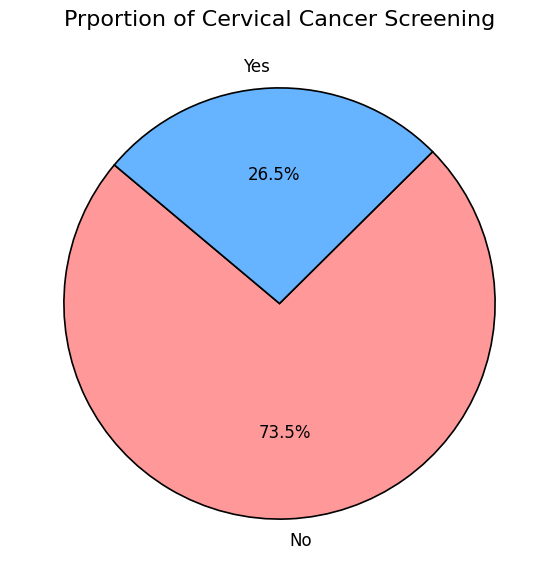

In [ ]:
import matplotlib.pyplot as plt

# Map 0/1 to No/Yes
y_mapped = df_selected["cervical_cancer_screened"].map({0: "No", 1: "Yes"})

# Calculate counts
counts = y_mapped.value_counts()
labels = counts.index
sizes = counts.values
colors = ['#ff9999','#66b3ff']  # Nice color palette

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',  # Show percentage
    startangle=140,     # Rotation
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2},  # Black border for wedges
    textprops={'fontsize': 12}
)
plt.title("Prportion of Cervical Cancer Screening", fontsize=16)
plt.show()


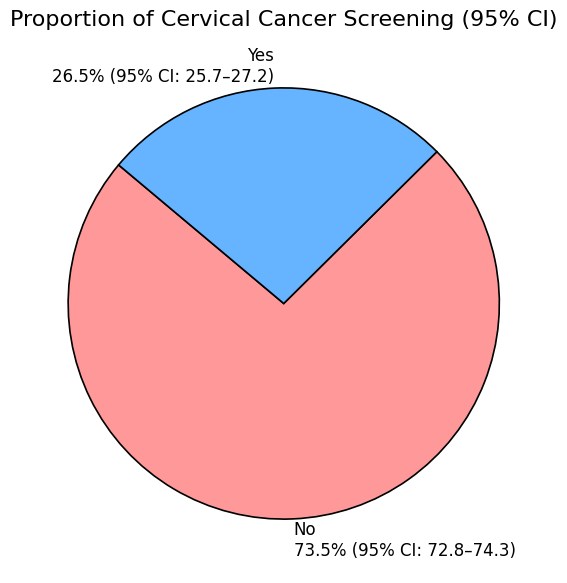

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Map 0/1 to No/Yes
y_mapped = df_selected["cervical_cancer_screened"].map({0: "No", 1: "Yes"})

# Counts
counts = y_mapped.value_counts()
n = counts.sum()

# Proportions
proportions = counts / n

# 95% CI (Normal approximation)
z = 1.96
ci_lower = proportions - z * np.sqrt((proportions * (1 - proportions)) / n)
ci_upper = proportions + z * np.sqrt((proportions * (1 - proportions)) / n)

# Create labels with CI
labels = [
    f"{label}\n{prop*100:.1f}% (95% CI: {low*100:.1f}–{up*100:.1f})"
    for label, prop, low, up in zip(
        proportions.index, proportions.values, ci_lower.values, ci_upper.values
    )
]

sizes = proportions.values
colors = ['#ff9999', '#66b3ff']
plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2},
    textprops={'fontsize': 12}
)

plt.title("Proportion of Cervical Cancer Screening (95% CI)", fontsize=16)
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features
numeric_features = df_selected.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_features.corr()

# Display correlation matrix as a heatmap
plt.figure(figsize=(16, 14))  # Increased figure size
sns.set(font_scale=1)       # Increase font scale for better readability
sns.heatmap(
    corr_matrix,
    annot=True,                # Show correlation values
    fmt=".2f",                 # Format
    cmap="coolwarm",           # Color map
    linewidths=1,              # Line width between cells
    cbar_kws={'shrink': 0.8}, # Colorbar size
    square=True
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()


NameError: name 'numeric_features' is not defined

In [ ]:
#df_selected=df_selected.drop(['residence'],axis=1) # have higher correlation with wealth index

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features
numeric_features = df_selected.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_features.corr()

# Display correlation matrix as a heatmap
plt.figure(figsize=(16, 14))  # Increased figure size
sns.set(font_scale=1)       # Increase font scale for better readability
sns.heatmap(
    corr_matrix,
    annot=True,                # Show correlation values
    fmt=".2f",                 # Format
    cmap="coolwarm",           # Color map
    linewidths=1,              # Line width between cells
    cbar_kws={'shrink': 0.8}, # Colorbar size
    square=True
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming X contains features and y contains the target
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # for reproducibility
    stratify=y           # keeps class distribution same in train and test
)

# Check the shape
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import pandas as pd

# ensure using training set only
y_train_mapped = y_train.map({0: "No", 1: "Yes"})

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

y_train_res_mapped = pd.Series(y_train_res).map({0: "No", 1: "Yes"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ["No", "Yes"]  # explicit category order used for both plots

# Before SMOTE
sns.countplot(x=y_train_mapped, order=order, palette="Set2", ax=axes[0])
axes[0].set_title("Before SMOTE", fontsize=14)
axes[0].set_xlabel("Cervical Cancer Screened", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

# Annotate counts by reading bar heights (robust)
for p in axes[0].patches:
    height = int(p.get_height())
    axes[0].text(p.get_x() + p.get_width() / 2., height + 5, str(height),
                 ha="center", fontsize=12)

# After SMOTE
sns.countplot(x=y_train_res_mapped, order=order, palette="Set2", ax=axes[1])
axes[1].set_title("After SMOTE", fontsize=14)
axes[1].set_xlabel("Cervical Cancer Screened", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

for p in axes[1].patches:
    height = int(p.get_height())
    axes[1].text(p.get_x() + p.get_width() / 2., height + 5, str(height),
                 ha="center", fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Random Forest Classifier
# -------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=None
)

# -------------------------------------------------------
# 2. Apply RFE
# -------------------------------------------------------
n_features_to_select = 10

rfe = RFE(
    estimator=rf,
    n_features_to_select=n_features_to_select,
    step=1
)

rfe.fit(X_train_res, y_train_res)

# -------------------------------------------------------
# 3. Build Ranking Table
# -------------------------------------------------------
ranking_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Rank": rfe.ranking_,
    "Selected": rfe.support_
}).sort_values(by="Rank", ascending=True)

print("Feature Ranking (1 = most important):")
print(ranking_df)

# -------------------------------------------------------
# 4. Clean Publication-Quality Plot (No Rank Labels)
# -------------------------------------------------------

plt.figure(figsize=(8, 10))

sorted_df = ranking_df.sort_values("Rank")

# Colors for selected vs non-selected features
colors = ["#1f77b4" if sel else "#c7d5e0" for sel in sorted_df["Selected"]]

plt.barh(
    y=sorted_df["Feature"],
    width=sorted_df["Rank"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# Invert y-axis so top-ranked features appear on top
plt.gca().invert_yaxis()

# Labels and title
plt.title("Feature Selection Using RFE (Random Forest)",
          fontsize=18, fontweight="bold")
plt.xlabel("Rank (1 = Best)", fontsize=16)
plt.ylabel("Features", fontsize=16)

# Grid lines
plt.grid(axis='x', linestyle="--", alpha=0.6)

# Remove outer box
plt.box(False)

plt.tight_layout()

# Save the figure high quality
plt.savefig("RFE_feature_ranking_clean.png", dpi=300, bbox_inches='tight')

plt.show()

# -------------------------------------------------------
# 5. Show only the selected features (Rank = 1)
# -------------------------------------------------------
print("\nTop Selected Features:")
print(ranking_df[ranking_df["Rank"] == 1])


In [ ]:
!pip install optuna

In [ ]:
!pip install catboost

In [ ]:
# ======================================================
# Full pipeline: Optuna + Final Models + Evaluation + ROC
# Revised with new model list (DT, RF, ET, AdaBoost, GBoost, Bagging, KNN…)
# ======================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML libraries
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, confusion_matrix,
    classification_report
)


# ======================================================
# 0. RFE-selected features
# ======================================================
selected_features = ranking_df[ranking_df["Selected"] == True]["Feature"].tolist()
print("Selected features (RFE):", selected_features)

X_train_sel = X_train_res[selected_features].copy()
X_test_sel  = X_test[selected_features].copy()

assert X_train_sel.shape[1] == len(selected_features)


# ======================================================
# FIX NaN ISSUE
# ======================================================
print("\nChecking NaN before cleaning:")
print("Train NaN:", X_train_sel.isna().sum().sum())
print("Test NaN :", X_test_sel.isna().sum().sum())

# Fill numeric
for col in X_train_sel.select_dtypes(include=[np.number]).columns:
    med = X_train_sel[col].median()
    X_train_sel[col].fillna(med, inplace=True)
    X_test_sel[col].fillna(med, inplace=True)

# Fill categorical
for col in X_train_sel.select_dtypes(include=['object']).columns:
    X_train_sel[col].fillna("Unknown", inplace=True)
    X_test_sel[col].fillna("Unknown", inplace=True)

print("\nChecking NaN AFTER cleaning:")
print("Train NaN:", X_train_sel.isna().sum().sum())
print("Test NaN :", X_test_sel.isna().sum().sum())
print("NaN fix complete ✔")


# ======================================================
# Evaluation function
# ======================================================
def evaluate_model(name, model, X_test, y_test):
    try:
        probs = model.predict_proba(X_test)[:, 1]
    except:
        try:
            scores = model.decision_function(X_test)
            probs = (scores - scores.min()) / (scores.max() - scores.min())
        except:
            probs = model.predict(X_test)

    preds = (probs >= 0.5).astype(int)

    return {
        "model": name,
        "roc_auc": roc_auc_score(y_test, probs),
        "pr_auc": average_precision_score(y_test, probs),
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, preds),
        "probs": probs
    }


# ======================================================
# 1. Optuna Objective Functions
# ======================================================

def optimize_decisiontree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10)
    }
    model = DecisionTreeClassifier(**params)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10)
    }
    model = RandomForestClassifier(**params, n_jobs=-1)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_extratrees(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 30)
    }
    model = ExtraTreesClassifier(**params, n_jobs=-1)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_adaboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 1.0)
    }
    model = AdaBoostClassifier(**params)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_gboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 2, 10)
    }
    model = GradientBoostingClassifier(**params)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_bagging(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 200)
    }
    model = BaggingClassifier(**params, n_jobs=-1)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_logistic(trial):
    C = trial.suggest_float("C", 1e-4, 100.0, log=True)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(C=C, max_iter=5000))
    ])
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 30)
    }
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(**params))
    ])
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42
    }
    model = XGBClassifier(**params, n_jobs=-1)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "random_state": 42
    }
    model = LGBMClassifier(**params, n_jobs=-1)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


def optimize_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "random_state": 42,
        "verbose": 0
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train_sel, y_train_res)
    preds = model.predict_proba(X_test_sel)[:, 1]
    return roc_auc_score(y_test, preds)


# ======================================================
# 2. Run Optuna Studies
# ======================================================
n_trials = 40

def run_search(func, name):
    print(f"\nStarting optimization for {name}...")
    study = optuna.create_study(direction="maximize")
    study.optimize(func, n_trials=n_trials, show_progress_bar=True)
    print(f"Best {name} ROC-AUC: {study.best_value:.4f}")
    print("Best Params:", study.best_params)
    return study.best_params


best_dt_params     = run_search(optimize_decisiontree, "DecisionTree")
best_rf_params     = run_search(optimize_rf, "RandomForest")
best_et_params     = run_search(optimize_extratrees, "ExtraTrees")
best_ada_params    = run_search(optimize_adaboost, "AdaBoost")
best_gb_params     = run_search(optimize_gboost, "GradientBoosting")
best_bag_params    = run_search(optimize_bagging, "Bagging")
best_lr_params     = run_search(optimize_logistic, "LogisticRegression")
best_knn_params    = run_search(optimize_knn, "KNN")
best_xgb_params    = run_search(optimize_xgb, "XGBoost")
best_lgbm_params   = run_search(optimize_lgbm, "LightGBM")
best_cat_params    = run_search(optimize_cat, "CatBoost")


# ======================================================
# 3. Train final models
# ======================================================
final_models = {}

final_models["DecisionTree"] = DecisionTreeClassifier(**best_dt_params).fit(X_train_sel, y_train_res)
final_models["RandomForest"] = RandomForestClassifier(**best_rf_params, n_jobs=-1).fit(X_train_sel, y_train_res)
final_models["ExtraTrees"] = ExtraTreesClassifier(**best_et_params, n_jobs=-1).fit(X_train_sel, y_train_res)
final_models["AdaBoost"] = AdaBoostClassifier(**best_ada_params).fit(X_train_sel, y_train_res)
final_models["GradientBoosting"] = GradientBoostingClassifier(**best_gb_params).fit(X_train_sel, y_train_res)
final_models["Bagging"] = BaggingClassifier(**best_bag_params, n_jobs=-1).fit(X_train_sel, y_train_res)

final_models["LogisticRegression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(C=best_lr_params["C"], max_iter=5000))
]).fit(X_train_sel, y_train_res)

final_models["KNN"] = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(**best_knn_params))
]).fit(X_train_sel, y_train_res)

final_models["XGBoost"] = XGBClassifier(**best_xgb_params, n_jobs=-1).fit(X_train_sel, y_train_res)
final_models["LightGBM"] = LGBMClassifier(**best_lgbm_params, n_jobs=-1).fit(X_train_sel, y_train_res)

cat_params = best_cat_params.copy()
cat_params.update({"random_state": 42, "verbose": 0})
final_models["CatBoost"] = CatBoostClassifier(**cat_params).fit(X_train_sel, y_train_res)


# ======================================================
# 4. Evaluate models + ROC curves
# ======================================================
results = []
plt.figure(figsize=(10, 8))

for name, model in final_models.items():
    res = evaluate_model(name, model, X_test_sel, y_test)
    results.append(res)
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ======================================================
# 5. Summary table + Top 2 confusion matrices
# ======================================================
summary = pd.DataFrame([{
    "Model": r["model"],
    "ROC_AUC": r["roc_auc"],
    "PR_AUC": r["pr_auc"],
    "Accuracy": r["accuracy"],
    "Precision": r["precision"],
    "Recall": r["recall"],
    "F1": r["f1"]
} for r in results]).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

print("\nModel Performance Summary:")
print(summary)

top_models = summary["Model"].head(2).tolist()

for tm in top_models:
    print(f"\n--- {tm} ---")
    model_obj = final_models[tm]
    try:
        probs = model_obj.predict_proba(X_test_sel)[:, 1]
        preds = (probs >= 0.5).astype(int)
    except:
        preds = model_obj.predict(X_test_sel)

    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds))


summary.to_csv("model_performance_summary.csv", index=False)
print("\nSaved summary to model_performance_summary.csv")


High-quality bar plot of TOPSIS **scores**

In [ ]:
!pip install topsis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# ---------------------------
# 1. TOPSIS PERFORMANCE TABLE
# ---------------------------
performance_df = pd.DataFrame([{
    "Model": r["model"],
    "ROC_AUC": r["roc_auc"],
    "Accuracy": r["accuracy"],
    "Precision": r["precision"],
    "Recall": r["recall"],
    "F1": r["f1"]
} for r in results])

performance_df.set_index("Model", inplace=True)

# ---------------------------
# 2. TOPSIS Implementation
# ---------------------------
# Step 1: Normalize the matrix
matrix = performance_df.values
norm_matrix = matrix / np.sqrt((matrix**2).sum(axis=0))

# ---------------------------
#  NEW WEIGHTS (sum = 1)
#  Since PR_AUC was removed, weights must match 5 metrics
#  Adjust these if needed.
# ---------------------------
weights = np.array([0.30, 0.20, 0.15, 0.15, 0.20])  # ROC_AUC, Acc, Prec, Recall, F1

weighted_matrix = norm_matrix * weights

# Step 3: Ideal best & worst
ideal_best = weighted_matrix.max(axis=0)
ideal_worst = weighted_matrix.min(axis=0)

# Step 4: Distances
dist_best = np.sqrt(((weighted_matrix - ideal_best)**2).sum(axis=1))
dist_worst = np.sqrt(((weighted_matrix - ideal_worst)**2).sum(axis=1))

# Step 5: TOPSIS score
performance_df['TOPSIS_score'] = dist_worst / (dist_best + dist_worst)
performance_df['Rank'] = performance_df['TOPSIS_score'].rank(ascending=False).astype(int)

# Sort by rank
performance_df = performance_df.sort_values('Rank')

print("\nTOPSIS ranking of models:")
print(performance_df[['TOPSIS_score', 'Rank']])

# ---------------------------
# 3. TOPSIS BAR CHART (HIGH QUALITY)
# ---------------------------
plt.figure(figsize=(12, 7), dpi=200)
bars = plt.barh(performance_df.index, performance_df['TOPSIS_score'],
                color="#1f78b4", edgecolor="black", linewidth=1.3)

plt.xlabel("TOPSIS Score", fontsize=16)
plt.ylabel("Models", fontsize=16)
plt.title("Model Ranking Using TOPSIS", fontsize=22, fontweight='bold')
plt.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.6)

# Annotate scores
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.005, bar.get_y() + bar.get_height()/2,
             f"{w:.3f}", fontsize=12, va='center')

plt.tight_layout()
plt.show()

# ================================================================
# ---------------------- SHAP ANALYSIS ----------------------------
# ================================================================

# Identify BEST model from TOPSIS
best_model_name = performance_df.index[0]
print("\nBest model according to TOPSIS:", best_model_name)

# Extract fitted model object from results list
best_model = [r["model_object"] for r in results if r["model"] == best_model_name][0]



In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np # Import numpy for ndarray check

# Identify the best model from the previous analysis (ExtraTrees had the highest TOPSIS score)
best_model_name = performance_df.index[0]  # Get the model with Rank 1
best_model = final_models[best_model_name] # Get model directly from final_models

print(f"Performing SHAP analysis for the best model: {best_model_name}")

# Ensure X_test_sel is a DataFrame for SHAP plots
# If it's a numpy array after previous operations, convert it back
if not isinstance(X_test_sel, pd.DataFrame):
    X_test_sel = pd.DataFrame(X_test_sel, columns=selected_features)

# Create a SHAP explainer
# For tree-based models like ExtraTrees, TreeExplainer is appropriate
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
# For binary classification, shap_values will be a list of two arrays (one for each class)
# or a 3D array (num_samples, num_features, num_classes).
# We need the values for the positive class (class 1).
shap_values = explainer.shap_values(X_test_sel)

# --- SHAP Summary Plot (Bar Chart) ---
print("\nGenerating SHAP Summary Plot (Bar Chart)...")
# If shap_values is a list (typical for TreeExplainer binary output), take the second element.
# If it's a 3D array, take the slice for class 1.
if isinstance(shap_values, list):
    shap_values_for_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_for_plot = shap_values[:, :, 1]
else: # Fallback, assume it's already the correct 2D array if not list/3D
    shap_values_for_plot = shap_values

shap.summary_plot(shap_values_for_plot, X_test_sel, plot_type="bar", show=False)
plt.title(f"SHAP Feature Importance for {best_model_name}")
plt.tight_layout()
plt.show()

# --- SHAP Waterfall Plot for a single instance ---
print("\nGenerating SHAP Waterfall Plot for a single instance...")
# Select an instance from the test set (e.g., the first one)
instance_index = 0
instance_data = X_test_sel.iloc[instance_index]
instance_shap_values = explainer.shap_values(instance_data)

# Waterfall plot for the positive class (assuming binary classification)
# Adjust base_values and shap_values indexing based on their structure.
# Check if explainer.expected_value is a sequence (list or 1D array) and has multiple elements.
if hasattr(explainer.expected_value, '__len__') and len(explainer.expected_value) > 1:
    expected_value_for_plot = explainer.expected_value[1]
else:
    # Assume it's a single scalar value if not a sequence with multiple elements
    expected_value_for_plot = explainer.expected_value

# Check if instance_shap_values is a sequence (list or 1D array) and has multiple elements.
if hasattr(instance_shap_values, '__len__') and len(instance_shap_values) > 1:
    instance_shap_values_for_plot = instance_shap_values[1]
else:
    # Assume it's already the 1D array for class 1 if not a sequence with multiple elements
    instance_shap_values_for_plot = instance_shap_values

shap.plots.waterfall(shap.Explanation(values=instance_shap_values_for_plot,
                                      base_values=expected_value_for_plot,
                                      data=instance_data,
                                      feature_names=X_test_sel.columns.tolist()))
plt.suptitle(f"SHAP Waterfall Plot for Instance {instance_index} ({best_model_name})")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import shap

print("\nGenerating SHAP Summary Plot (Dot Plot)...")

# Assuming shap_values_for_plot and X_test_sel are already defined from previous execution
# (shap_values_for_plot contains SHAP values for the positive class (class 1))

plt.figure(figsize=(12, 7), dpi=200)
shap.summary_plot(shap_values_for_plot, X_test_sel, show=False)
plt.title(f"SHAP Summary Dot Plot – {best_model_name}", fontsize=18)
plt.tight_layout()
plt.show()

Radar plot of metrics + TOPSIS ranking

In [ ]:
from math import pi

# Metrics for radar
metrics = ["ROC_AUC", "Accuracy", "Precision", "Recall", "F1"]
num_metrics = len(metrics)

# Angle for each axis
angles = [n / float(num_metrics) * 2 * pi for n in range(num_metrics)]
angles += angles[:1]  # complete circle

plt.figure(figsize=(8,8), dpi=150)
ax = plt.subplot(111, polar=True)

# Plot each model
for idx, row in performance_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]  # complete circle
    ax.plot(angles, values, linewidth=2, label=f"{idx} (Rank {row['Rank']})")
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], metrics, fontsize=12)
plt.yticks(fontsize=10)
plt.title("Model Performance Radar + TOPSIS Ranking", fontsize=18, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05))
plt.show()
